![Astrofisica Computacional](../../../logo.PNG)

---
## 01. Simplectic Integrators 

Eduard Larrañaga (ealarranaga@unal.edu.co)

---


### Abstract

In this notebook, we present the use of LeapFrog y Verlet integrators ot solve ODEs.

`A. Garcia. Numerical Methods for Physics. (1999). Chapter 3 `

---

## LeapFrog Integrator

Consider the following system of ODEs,

\begin{equation}
\frac{d^2 x}{dt^2} = a(x),
\end{equation}

which can be written as the first-order differential system

\begin{align}
\begin{cases}
\frac{d x}{dt} = &v \\
\frac{dv}{dt} = & a(x).
\end{cases}
\end{align}


**Note the dependency of the function $a = a(x(t))$ on the right hand side of the equations.**

Discretization of the time derivative (using centered differences) in the second equation results in

\begin{equation}
\frac{v(t+\Delta t) - v(t-\Delta t)}{2\Delta t} + \mathcal{O}(\Delta t^2)= a(x).
\end{equation}

In the first differential equation a centered discretization of the derivative will also be used, but in this case it will be centered on the point $t+\Delta t$ (this means that the points $t+2\Delta t$ and $ t$ in the finite difference). With this you get

\begin{equation}
\frac{x(t+2\Delta t) - x(t)}{2\Delta t} + \mathcal{O}(\Delta t^2)= v(t+\Delta t).
\end{equation}

These two difference equations are written iteratively as,

\begin{align}
\begin{cases}
\frac{x_{n+2} - x_n}{2\Delta t} + \mathcal{O}(\Delta t^2) &= v_{n+1} \\
\frac{v_{n+1} - v_{n-1}}{2\Delta t} + \mathcal{O}(\Delta t^2) &= a_n.
\end{cases}
\end{align}

Rearranging these equations, we obtain the iteratio method known as **Leap-Frog**,

\begin{align}
\begin{cases}
v_{n+1} &= v_{n-1} + 2 a_n \Delta t + \mathcal{O}(\Delta t^3)\\
x_{n+2} &= x_n + 2 v_{n+1}\Delta t + \mathcal{O}(\Delta t^3)
\end{cases}
\end{align}

This is a $\mathcal{O}(\Delta t^3)$ order method and its name comes from the fact that the solution is built with steps of size $2\Delta t$, with the position function $x$ moving forward on even values, $x_0, x_2, x_4, ...$, while the speed function $v$ advances on odd values ​​$v_1, v_3, v_5, ...$.

In some references, the LeapFrog method equations are written in the following form (equivalent to the *Euler-Cromer* method):

\begin{align}
\begin{cases}
v_{n+\frac{1}{2}} &= v_{n-\frac{1}{2}} + a_n \Delta t + \mathcal{O}(\Delta t^3)\\
x_{n+1} &= x_n + v_{n+\frac{1}{2}}\Delta t + \mathcal{O}(\Delta t^3)
\end{cases}
\end{align}

The origin of the name of this method is in the dependency of the function $a=a(x)$, which implies that its value must be evaluated at an instant of time centered between the old and new values ​​of the function $v$ .

<center>
<img src="https://i.ibb.co/p1Pb63S/Screen-Shot-2021-06-08-at-7-11-33-PM.png" alt="Screen-Shot-2021-06- 08-at-7-11-33-PM" border="0"></a>
</center>

The LeapFrog method is computationally more efficient than the Predictor-Corrector method and requires less data storage. Being one of the **simplectic** algorithms (i.e. that preserves the area in the phase space §), the conservation of energy is respected, even with large time steps. In this way, this type of algorithm can achieve an appreciable decrease in computation time. However, in some cases where more precise position and velocity values ​​are required, algorithms such as Predictor-Corrector or RK methods are often preferred.


§ It can be shown that the Leapfrog algorithm preserves the areas enclosed by the trajectories in phase space (p vs. x) throughout the evolution of the system. This implies that energy is conserved during evolution.

### LeapFrog Method Initiation

The Leap-Frog method does not *auto-start* because, in addition to the initial values ​​,$(x_0, v_0)$, it is necessary to know the value $v_{-1}$. One of the possibilities to start the algorithm is to perform a backward Euler step to obtain the required information,
\begin{align}
v_{-1} = &v_0 - a_0\Delta t,
\end{align}

or half a step backwards if the equations are written in the second form presented,
\begin{align}
v_{-\frac{1}{2}} = &v_0 - \frac{1}{2} a_0 \Delta t.
\end{align}

It can be shown that the LeapFrog method is much faster and more stable than Euler's method.

El sistema de ODEs es implementado mediante una función cuya dependencia es únicamente $f(x)$,

In [1]:
import numpy as np

# Newtonian Gravitational Constant
G = 4.*np.pi**2
M = 1.

def ODE(q0):
    '''
    ------------------------------------------
    ODE(q0) 
    ------------------------------------------
    ODEs system for the motion of test body 
    (e.g. Earth) around the Sun using 
    cartesian coordinates in the orbital plane.
    ------------------------------------------
    Arguments:
    q0: NumPy array with the coordinates 
        defined as
    q0[0] = x: coordinate x
    q0[1] = y: coordinate y
    ------------------------------------------
    Returns:
    a = NumPy array with the components of the 
        acceleration
    '''
    r2 = q0[0]**2 + q0[1]**2
    a = - G*M*q0[0:2]/r2**(3/2)
    return a


--- 
## Initial Condition

In order to illustrate the use of the LeapFrog method, we will use the initial condition used to probe the Euler and RK4 methods,

- The initial position is given by $x_0 = 1 \text{ au}$ and $y_0 = 0 \text{ au}$ 
- The initial velocity is given by $v^x_0=0 \text{ au/yr}$ and $v^y_0 = 3 \text{ au/yr}$.

We will consider an integration domain for the tiemporal coordinate from $t_0 = 0$ to $t_f = 20$ years with one million steps.


**Note:** The Leap-Frog does not self-initiate because we need to know the initial conditions, $(x_0, y_0)$ and $(v^x_0, v^y_0)$, together with some previous values $(v^x_{-1} and v^y_{-1})$. In order to obtain these previous values, we may use a backwards Euler step,
\begin{align}
v^x_{-1} = &v^x_0 - h a^x(x_0,y_0) \\
v^y_{-1} = &v^y_0 - h a^y(x_0,y_0).
\end{align}

## Solving the ODEs System


In [9]:
def LeapFrog(h, q0):
    '''
    ------------------------------------------
    LeapFrog(h, q0)
    ------------------------------------------
    LeapFrog method for solving a ODEs system.
    Arguments:
    h: stepsize for the iteration
    t0: independent parameter initial value
    q0: numpy array with the initial values of
        the functions in the ODEs system
        q[0] : x
        q[1] : y
        q[2] : dx/dt
        q[3] : dx/dt
    ------------------------------------------
    '''
    ax, ay = ODE(q0)
    q1 = np.zeros(q0.shape)
    q1[2] = q0[2] + 2*h*ax
    q1[3] = q0[3] + 2*h*ay
    q1[0] = q0[0] +2*h*q1[2]
    q1[1] = q0[1] +2*h*q1[3]
    return q1

# Creation of the time grid (in years)
t_0 = 0.
t_f = 20.

# Number of steps in the grid
n = 1000000

# Constant stepsize defined by the number of steps in the grid
h = (t_f - t_0)/n

# Arrays to store the solution
t = np.linspace(t_0, t_f, n) # Time information
Q = np.zeros([n,4]) #  Motion information

# Initial Conditions
Q[0,0] = 1. # initial x
Q[0,1] = 0. # initial y
Q[0,2] = 0. # initial vx
Q[0,3] = 3. # initial vy

# Half step backwards to inizialize the velocity
ax0, ay0 = ODE(Q[0])
Q[0,2] = Q[0,2] - h*ax0
Q[0,3] = Q[0,3] - h*ay0
             
# Main loops for solving the problem
for i in range(1,n):
    Q[i,:] = LeapFrog(h, Q[i-1,:])


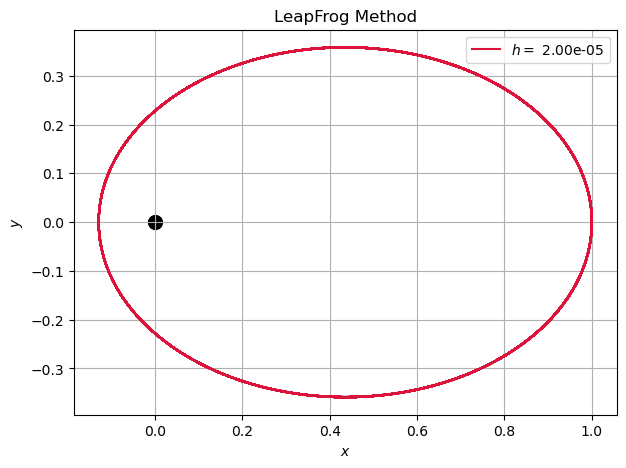

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(Q[:,0], Q[:,1], color='crimson', label=f'$h=$ {h:.2e}')
ax.scatter(0,0, color='black', s=100)
ax.set_title('LeapFrog Method')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')
ax.legend()
ax.grid()

plt.show()

It is clear that the LeapFrog method is faster and more stable than Euler's method.

---

Now, we will probe the behavior of the the conserved quantities under the LeapFrog integration,

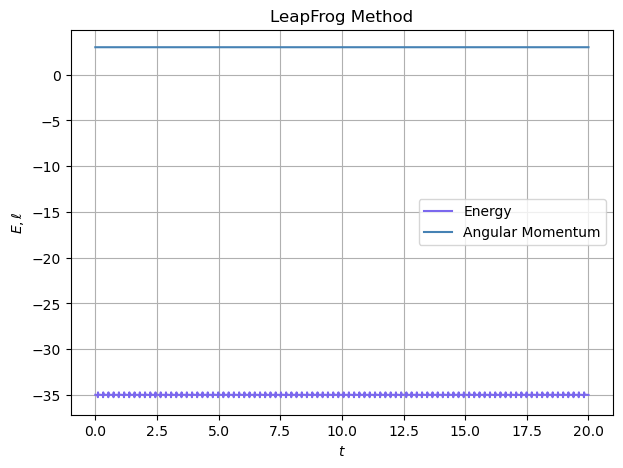

In [12]:
Energy = np.zeros(n)
AngMom = np.zeros(n)

for i in range(n):
    speed2 = Q[i,2]**2 + Q[i,3]**2
    r = np.sqrt(Q[i,0]**2 + Q[i,1]**2)
    Energy[i] = speed2/2 - G*M/r
    AngMom[i] = Q[i,0]*Q[i,3] - Q[i,1]*Q[i,2]


fig, ax = plt.subplots( figsize=(7,5))
ax.plot(t, Energy, color='mediumslateblue', label=f'Energy')
ax.plot(t, AngMom, color='steelblue', label=f'Angular Momentum')
ax.set_title('LeapFrog Method')
ax.set_xlabel(r'$t$')
ax.set_ylabel(r'$E, \ell$')
ax.grid()
ax.legend()

plt.show()

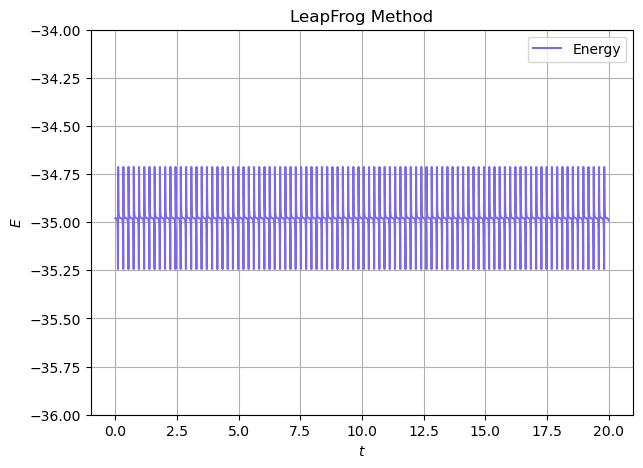

In [21]:
fig, ax = plt.subplots( figsize=(7,5))

ax.plot(t, Energy, color='mediumslateblue', label=f'Energy')
ax.set_title('LeapFrog Method')
ax.set_xlabel(r'$t$')
ax.set_ylabel(r'$E$')
ax.set_ylim(-36., -34.)
ax.grid()
ax.legend()

plt.show()

The mean of the energy along the integration domain coincides with the initial value,

In [19]:
Energy[0], Energy.mean()

(-34.97841729264834, -34.97840468380789)

---
##  Verlet's Method

Consider the second order ODE

\begin{equation}
\frac{d^2 x}{dt^2} = a(x)
\end{equation}

written in the form

\begin{align}
\begin{cases}
\frac{d x}{dt} = &v \\
\frac{d^2 x}{dt^2} = & \frac{dv}{dt} =  a(x(t)).
\end{cases}
\end{align}

We will use centered diferences to calculate the first and the second derivative to obtain the iterative equations

\begin{align}
\begin{cases}
\frac{x_{n+1} - x_{n-1}}{2h}  + \mathcal{O} (h^2) &= v_n \\
\frac{x_{n+1} - 2x_n + x_{n-1}}{h^2} + \mathcal{O} (h^2)  &= a(x_n).
\end{cases}
\end{align}

Re-writing this equation, we obtain

\begin{align}
\begin{cases}
v_n &= \frac{x_{n+1} - x_{n-1}}{2h}  + \mathcal{O} (h^2) \\
x_{n+1} &= 2x_n - x_{n-1} + h^2 a(x_n) + \mathcal{O} (h^4) .  
\end{cases}
\end{align}

This scheme is known as the **Verlet** method. Note that this method does not self-initialize (as the LeapFrog method) because we need the value of $x_n$ as well as of $x_{n-1}$ to obtain $x_{n+1}$. It is also important to note that the evolution of the position of partticle may be obtained independent of its velocity.

In [22]:
def Verlet(h, q0, s0):
    '''
    ------------------------------------------
    Verlet(h, q0, s0)
    ------------------------------------------
    Verlet method for solving a ODEs system.
    It needs to points to inizialize.
    ------------------------------------------
    Arguments:
    h: stepsize for the iteration
    q0: numpy array with the values of the
        coordinates in the n-step 
        q0[0] : x(n)
        q0[1] : y(n)
     s0: numpy array with the values of the
        coordinates in the (n-1)-step 
        s0[0] : x(n-1)
        s0[1] : y(n-1)
    ------------------------------------------
    Returns:
    Right hand side of the ODEs system as q1:
    q1[0] : x(n+1)
    q1[1] : y(n+1)
    q1[2] : vx(n)
    q1[3] : vy(n)
    ------------------------------------------
    '''
    ax, ay = ODE(q0)
    q1 = np.zeros(q0.shape)
    q1[0] = 2*q0[0] - s0[0] + ax*h**2
    q1[1] = 2*q0[1] - s0[1] + ay*h**2
    q1[2] = (q1[0] - s0[0])/(2*h)
    q1[3] = (q1[1] - s0[1])/(2*h)
    return q1



# Creation of the time grid (in years)
t_0 = 0.
t_f = 20.

# Number of steps in the grid
n = 1000000

# Constant stepsize defined by the number of steps in the grid
h = (t_f - t_0)/n

# Arrays to store the solution
t = np.linspace(t_0, t_f, n) # Time information
Q = np.zeros([n,4]) #  Motion information

# Initial Conditions
Q[0,0] = 1. # initial x
Q[0,1] = 0. # initial y
Q[0,2] = 0. # initial vx
Q[0,3] = 3. # initial vy

# Verlet algorithm needs to values of the coordinates to inizialize
# Therefore we take one backward Euler step to begin

S = np.zeros(2)

ax0, ay0 = ODE(Q[0])
S[0] = Q[0,0] - h*Q[0,2] + 0.5*ax0*h**2
S[1] = Q[0,1] - h*Q[0,3] + 0.5*ay0*h**2

Q[1,:] = Verlet(h, Q[0,:], S)

# Main loops for solving the problem

for i in range(2,n):
  Q[i,:] = Verlet(h, Q[i-1,:], Q[i-2,0:2])


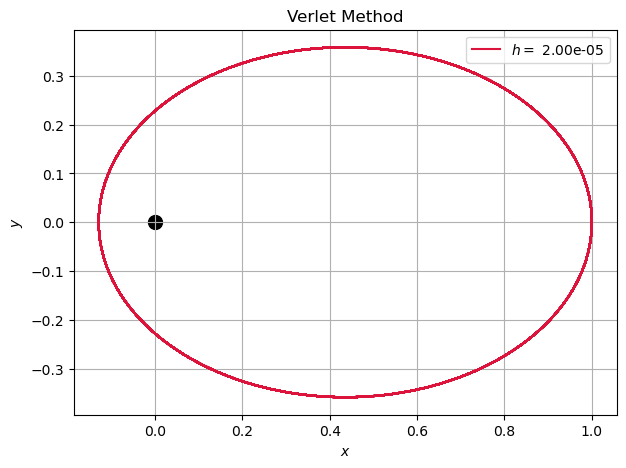

In [24]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(Q[:,0], Q[:,1], color='crimson', label=f'$h=$ {h:.2e}')
ax.scatter(0,0, color='black', s=100)
ax.set_title('Verlet Method')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')
ax.grid()
ax.legend()

plt.show()

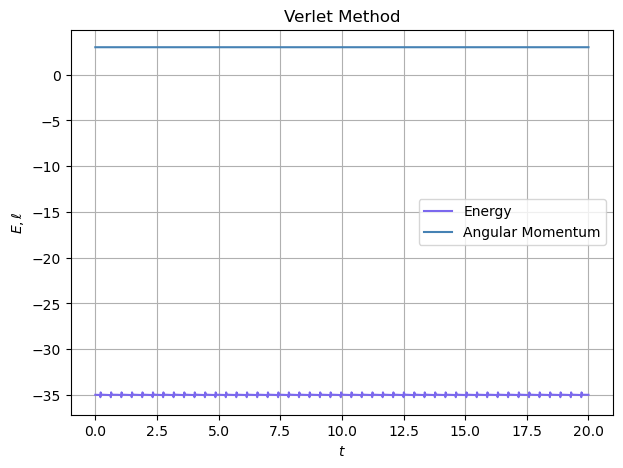

In [27]:
Energy = np.zeros(n)
AngMom = np.zeros(n)

for i in range(n):
    speed2 = Q[i,2]**2 + Q[i,3]**2
    r = np.sqrt(Q[i,0]**2 + Q[i,1]**2)
    Energy[i] = speed2/2 - G*M/r
    AngMom[i] = Q[i,0]*Q[i,3] - Q[i,1]*Q[i,2]


fig, ax = plt.subplots( figsize=(7,5))

ax.plot(t, Energy, color='mediumslateblue', label=f'Energy')
ax.plot(t, AngMom, color='steelblue', label=f'Angular Momentum')
ax.set_title('Verlet Method')
ax.set_xlabel(r'$t$')
ax.set_ylabel(r'$E, \ell$')
ax.grid()
ax.legend()

plt.show()

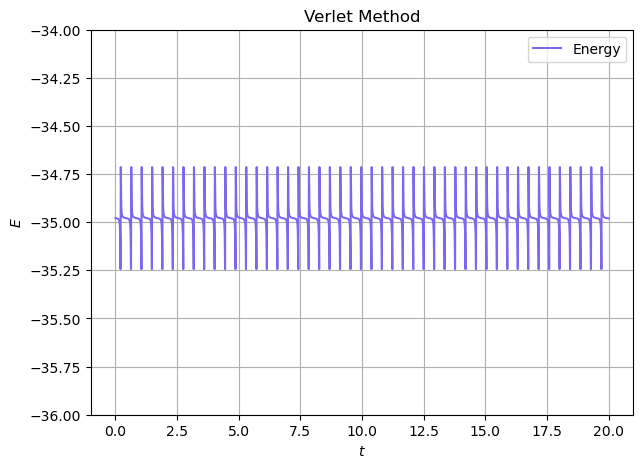

In [28]:
fig, ax = plt.subplots( figsize=(7,5))

ax.plot(t, Energy, color='mediumslateblue', label=f'Energy')
ax.set_title('Verlet Method')
ax.set_xlabel(r'$t$')
ax.set_ylabel(r'$E$')
ax.set_ylim(-36., -34.)
ax.grid()
ax.legend()

plt.show()

---

Now, we will probe the behavior of the the conserved quantities under the Verlet integration,

In [31]:
Energy[0], Energy.mean()

(-34.97841760435743, -34.978424647533586)